# Lab 05: The Dark Companion, Two Years Later

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import emcee #MCMC
import corner #scatterplot matrices that visualize multidimensional samples and covariances
from scipy.optimize import minimize
import scipy.signal
from astropy.timeseries import LombScargle

NETID = 'zahisr2'   # <-- set this
d = np.genfromtxt(f'../../labs/05/data/{NETID}.csv', delimiter=',', names=True)
t, rv, sig = d['t_days'], d['rv_kms'], d['sigma_rv_kms']
print(f"{t.size} epochs over {t.max() - t.min():.0f} days; median quoted error {np.median(sig):.2f} km/s")

def kepler_rv(t, P, K, e, omega, Tp, gamma):
    """Radial velocity of the visible star in a Keplerian orbit.
    P period [d], K semi-amplitude [km/s], e eccentricity, omega argument of periastron [rad],
    Tp a time of periastron [d], gamma systemic velocity [km/s]. Solves Kepler's equation by Newton iteration."""
    M = 2. * np.pi * ((t - Tp) / P % 1.0)            # mean anomaly
    E = M.copy()                                     # eccentric anomaly
    for _ in range(30):
        E = E - (E - e * np.sin(E) - M) / (1. - e * np.cos(E))
    nu = 2. * np.arctan2(np.sqrt(1. + e) * np.sin(E / 2.), np.sqrt(1. - e) * np.cos(E / 2.))   # true anomaly
    return gamma + K * (np.cos(nu + omega) + e * np.cos(omega))

def mass_function(P, K, e):
    """f(M) in solar masses, for P in days and K in km/s."""
    return 1.0361e-7 * (1. - e**2)**1.5 * K**3 * P

31 epochs over 835 days; median quoted error 2.02 km/s


## Part 1: Look first, then find the period (15%)


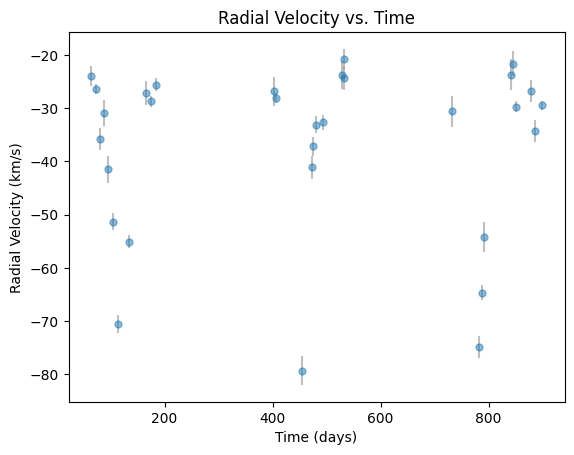

In [39]:
plt.errorbar(t, rv, sig, fmt='.', ecolor='gray', markersize=10, alpha=0.5);
plt.xlabel('Time (days)')
plt.ylabel('Radial Velocity (km/s)')
plt.title(f'Radial Velocity vs. Time');

In [77]:
ls = LombScargle(t, rv, sig) #weighted LS periodogram
freq, power = ls.autopower(minimum_frequency = 1 / 900, maximum_frequency = 1 / 10, samples_per_peak = 10)
period = 1.0 / freq
# 1/900 is longest possible orbit, and 1/10 is very high upper bound 
# for fastest orbit looking at the plot above

P = 166.1 d, power = 0.731
P = 115.5 d, power = 0.514
P = 83.3 d, power = 0.411
166.6


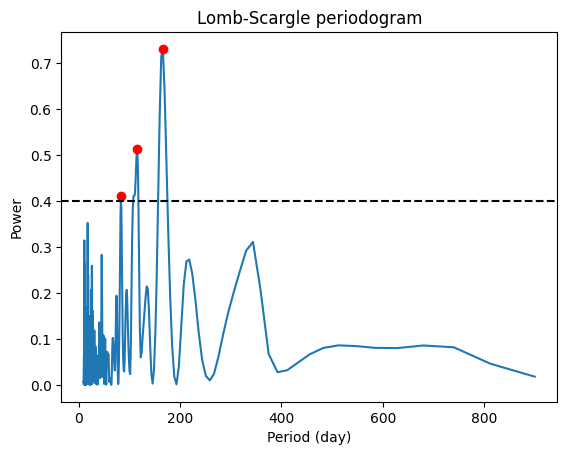

In [78]:
peaks, _ = scipy.signal.find_peaks(power) #local maxima scipy
top3 = peaks[np.argsort(power[peaks])[-3:][::-1]]
cands = period[top3]

for p, pw in zip(cands, power[top3]):
    print(f"P = {p:.1f} d, power = {pw:.3f}")
print(83.3 * 2)
plt.plot(period, power)
plt.plot(period[top3], power[top3], 'ro')
plt.axhline(0.40, color='black', ls='--')
#plt.xscale('log') -> wanted to see the the peaks better
plt.xlabel('Period (day)')
plt.ylabel('Power')
plt.title('Lomb-Scargle periodogram');

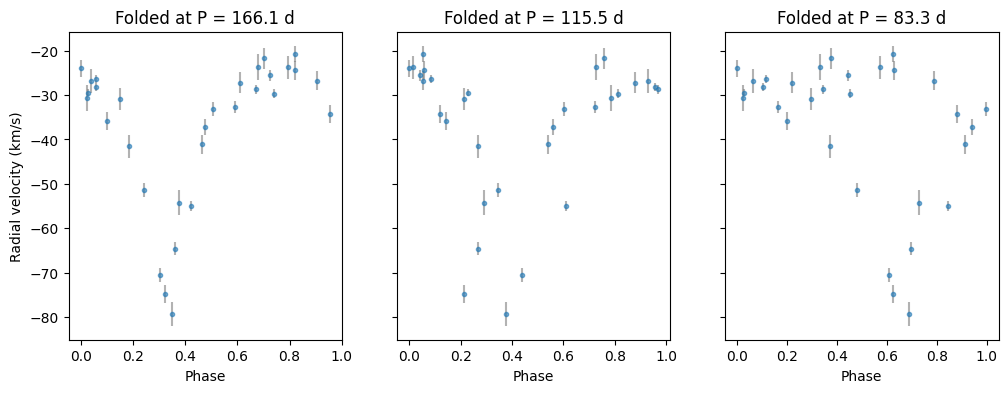

In [85]:
fig, axs = plt.subplots(1, 3, figsize=(12,4), sharey=True)
for ax, P in zip(axs, cands):
    phase = ((t - t.min()) / P) % 1.0
    ax.errorbar(phase, rv, sig, fmt='.', ecolor='gray', alpha=0.6)
    ax.set_title(f'Folded at P = {P:.1f} d')
    ax.set_xlabel('Phase')
axs[0].set_ylabel('Radial velocity (km/s)')
plt.show()

In [80]:
print((1/166.1 + 1/365.25)**-1) #aliasing period is the second candidate approx.

114.17714312599982


The periodogram has 3 plausible peaks at around 166, 115, and 83 days (with their powers decreasing respectively). The best candidate for period is 166.1 days as the curve is the most connected and visible. Sinuosodial fitting of an ellipctical orbit can be tricky because the observed measurements may look like a very different more agressive curve when objects are closest to the other object the binary (non-sinusodial).

The third candidate (83.3 d) is the worst as there is a dip in the radial velocities but there seems to be another curve reaching over the dip and connecting to the baseline. Furthermore, two times this period is almost the best candidate exactly, and the potential of two curves makes sense if folding was done incorrectly at a ratio of the true period. The second candidate (155.5 d) has a clearer dip in the curve but it is not a uniform curve at the minimum. Referring to back to lesson 7's content, we see that this point may be an alias (the true frequency offset by the sampling frequency of the experiment). In the cell above using the best candidate for frequency (1/166.1 d) with the frequency of observation (1/365.25 d). The best candidate, P = 166.1 d has the clearest defined dip with a clear connection between points along a curve with the highest power.

## Part 2: Sample the posterior (40%)

In [86]:
def unpack(theta):
    P, K, h, k, Tp, gamma, ln_s = theta
    e = h**2 + k**2
    omega = np.arctan2(k, h)
    return P, K, e, omega, Tp, gamma, np.exp(ln_s)

def log_likelihood(theta):
    P, K, e, omega, Tp, gamma, s = unpack(theta)
    if e >= 0.99 or K <= 0 or P <= 0:
        return -np.inf
    model = kepler_rv(t, P, K, e, omega, Tp, gamma)
    var = sig**2 + s**2
    return -0.5 * np.sum((rv - model)**2 / var + np.log(2 * np.pi * var))

In [87]:
def log_prior(theta):
    P, K, h, k, Tp, gamma, ln_s = theta
    if not (10 < P < 900):
        return -np.inf
    if not (0 < K < 200):
        return -np.inf
    if not (h**2 + k**2 < 0.99):
        return -np.inf
    if not (abs(Tp - Tp0) < P0 / 2):
        return -np.inf
    if not (-200 < gamma < 200):
        return -np.inf
    if not (-10 < ln_s < 3):
        return -np.inf
    return 0.0

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

In [88]:
nll = lambda theta: -log_likelihood(theta)

fits = []
for P_start in cands:
    for omega_start in [0, np.pi/2, np.pi, 3*np.pi/2]:
        for frac in [0, 0.25, 0.5, 0.75]:
            x0 = [P_start,
                  (rv.max() - rv.min()) / 2,
                  np.sqrt(0.5) * np.cos(omega_start),
                  np.sqrt(0.5) * np.sin(omega_start),
                  t.min() + frac * P_start,
                  np.mean(rv),
                  0.0]
            res = minimize(nll, x0, method='Nelder-Mead',
                           options={'maxiter': 20000, 'maxfev': 20000})
            fits.append((-res.fun, P_start, res.x))

fits.sort(key=lambda f: f[0], reverse=True)

for P_start in cands:
    logL, _, x = max([f for f in fits if f[1] == P_start], key=lambda f: f[0])
    print(f"start P = {P_start:.1f} d  ->  fitted P = {x[0]:.2f} d,  logL = {logL:.2f}")

best = fits[0][2]
P0, Tp0 = best[0], best[4]
print("best:", best)

start P = 166.1 d  ->  fitted P = 164.18 d,  logL = -75.94
start P = 115.5 d  ->  fitted P = 113.69 d,  logL = -108.94
start P = 83.3 d  ->  fitted P = 82.00 d,  logL = -118.98
best: [ 1.64179767e+02  2.85116424e+01 -7.28974294e-01 -5.48290869e-15
  1.20952082e+02 -3.81560666e+01  7.29983739e-01]


The maximum-likelihood fits confirmed that the candidate with the highest power of the periodogram was a period of 164.18 days. The log likelihood of the runner-up candidate is the alias is worse than the best candidate by around 33.

100%|██████████| 10000/10000 [02:15<00:00, 73.68it/s]


tau: [81.03644352 84.58655534 78.96875111 75.33960578 76.10858817 78.95753137
 73.67719499]
burn-in: 422  thin: 42
independent-ish samples: (14592, 7)


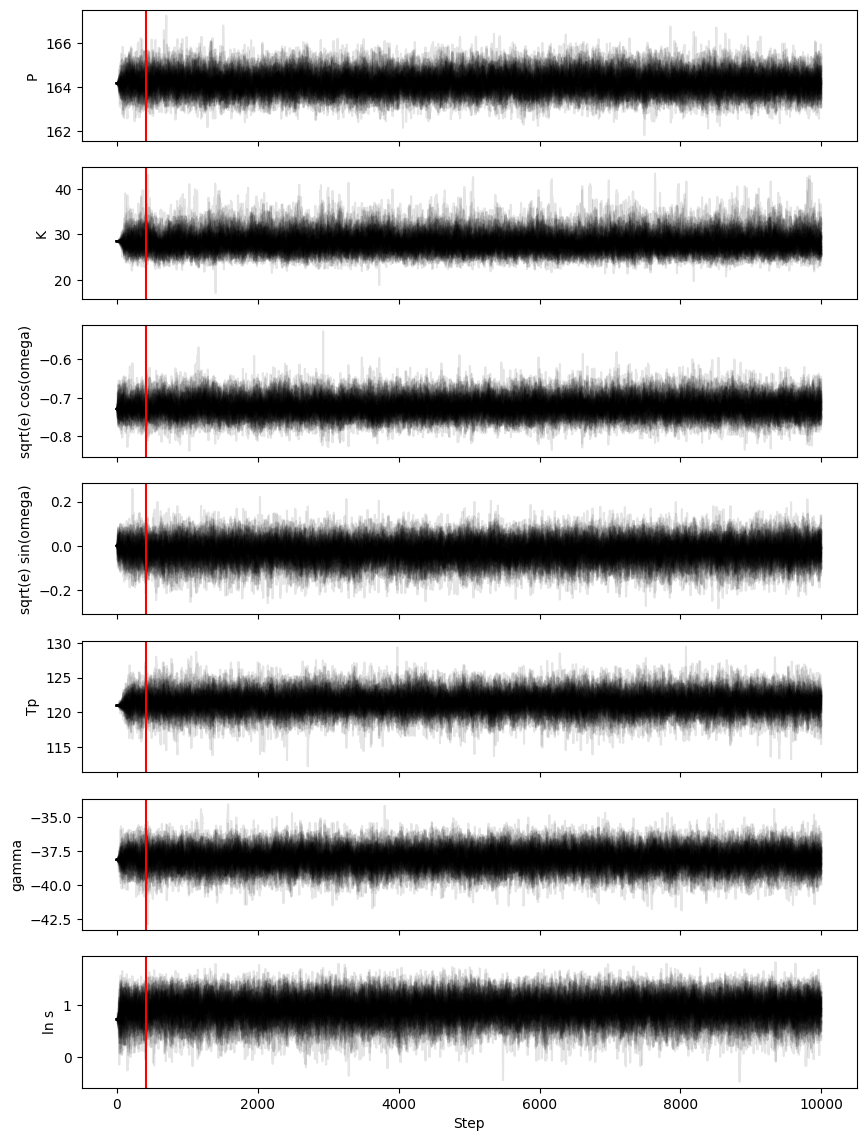

In [89]:
np.random.seed(457)
nwalkers, ndim = 64, 7
p0 = best + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(p0, 10000, progress=True)

tau = sampler.get_autocorr_time()
print("tau:", tau)
burn = int(5 * tau.max())
thin = int(tau.max() / 2)
print("burn-in:", burn, " thin:", thin)

samples = sampler.get_chain(discard=burn, thin=thin, flat=True)
print("independent-ish samples:", samples.shape)

labels = ['P', 'K', 'sqrt(e) cos(omega)', 'sqrt(e) sin(omega)', 'Tp', 'gamma', 'ln s']
chain = sampler.get_chain()
fig, axs = plt.subplots(ndim, 1, figsize=(10, 14), sharex=True)
for i in range(ndim):
    axs[i].plot(chain[:, :, i], color='k', alpha=0.1)
    axs[i].axvline(burn, color='r')
    axs[i].set_ylabel(labels[i])
axs[-1].set_xlabel('Step')
plt.show()

The autocorrelation times from `get_autocorr_time()` came out between about 74 and 85 steps, with a max of 84.6, which fits the expected 50 to 100 range. The chain is 10,000 steps, about 118 times the longest tau, so it clears the 50 tau rule, and get_autocorr_time ran without a warning. I discarded the first 422 steps (5 x tau_max) as advised and I thinned by 42 (roughly tau_max / 2) because neighboring steps are essentially copies of each other (~14.5k samples). After the burn in, the plots stay relatively the same with no significant drift around their center signifying convergance.

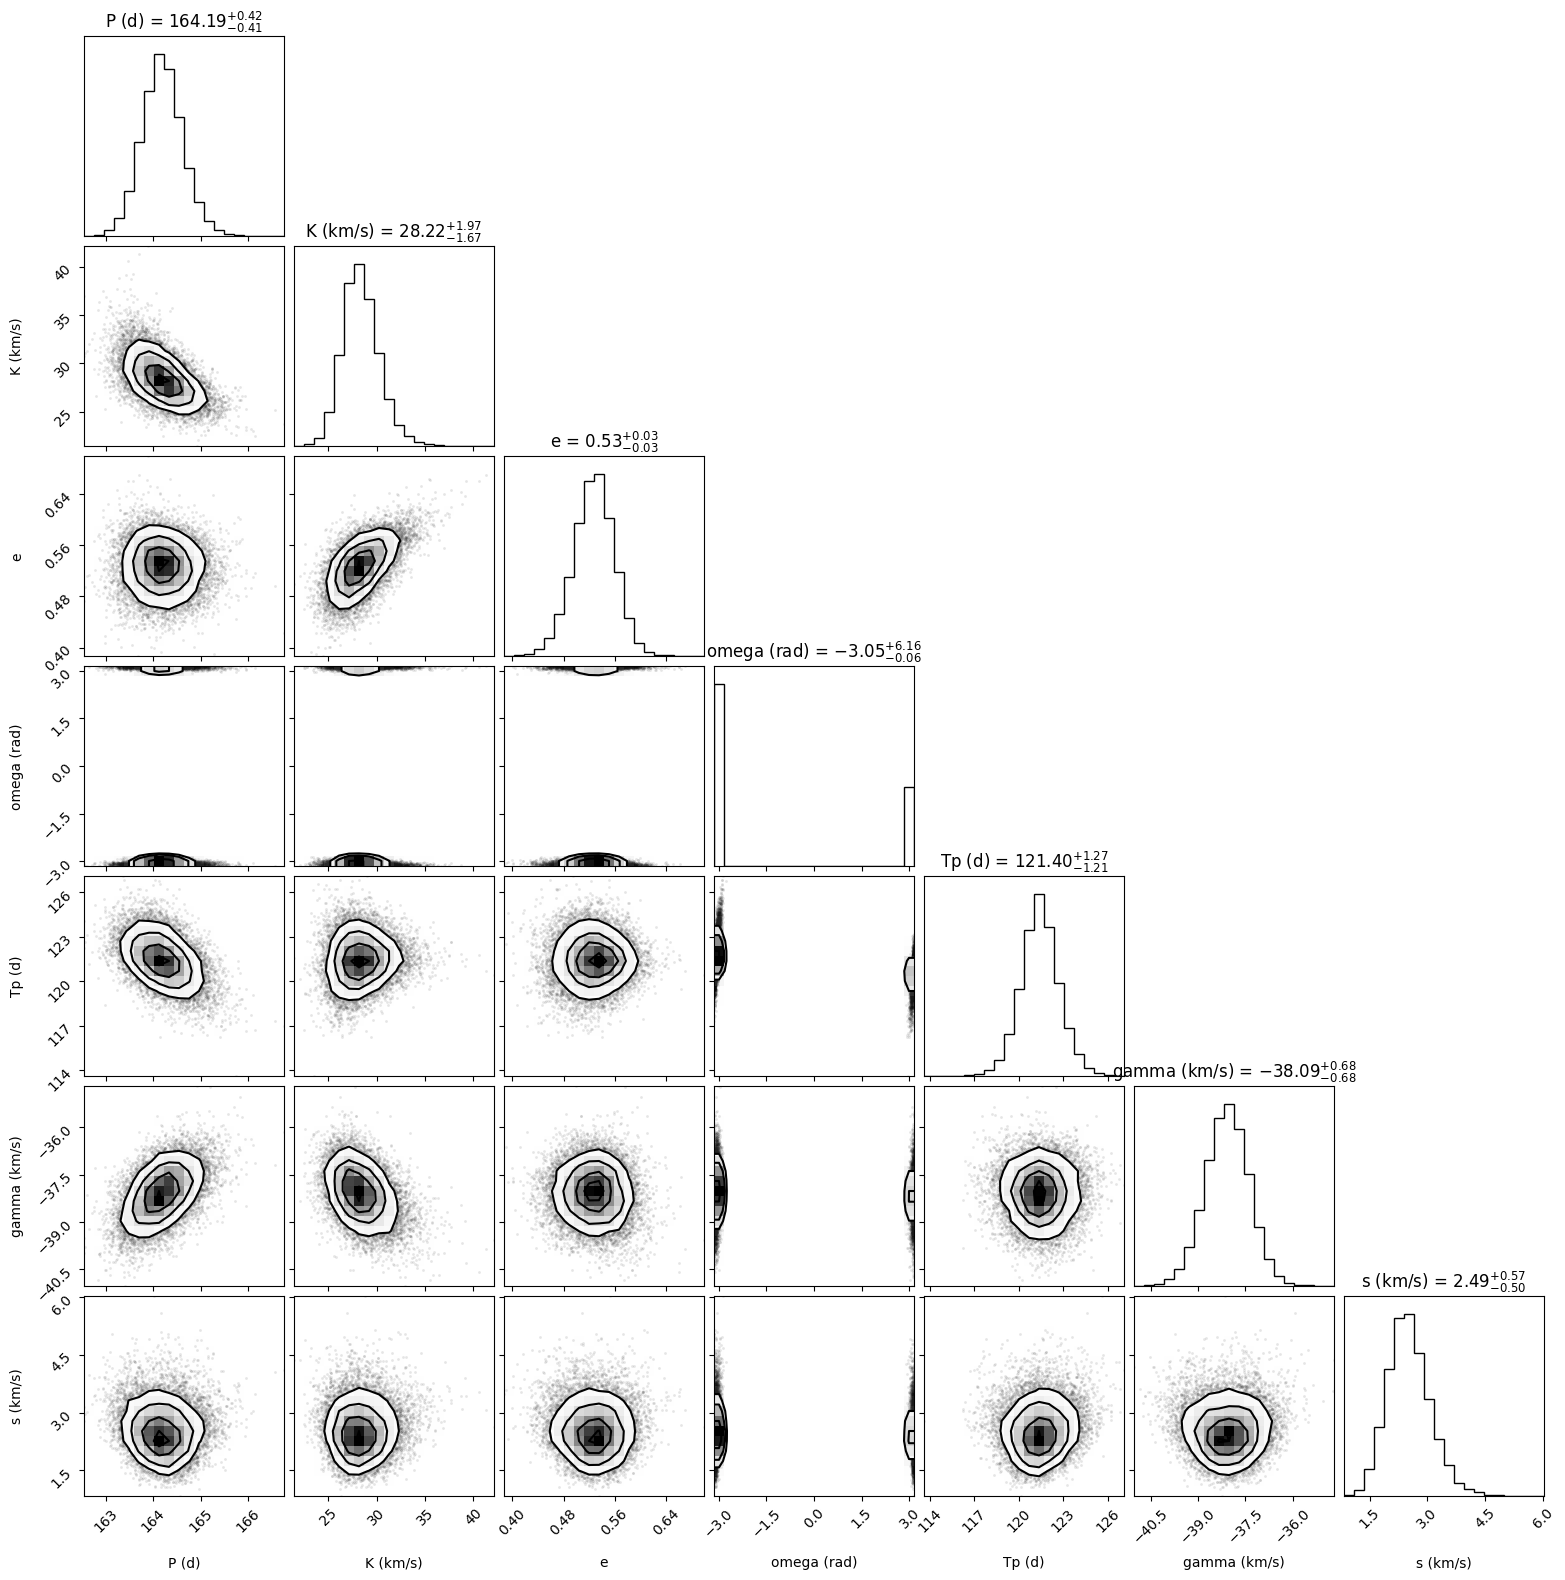

In [90]:
P, K, h, k, Tp, gamma, ln_s = samples.T
e = h**2 + k**2
omega = np.arctan2(k, h)
s = np.exp(ln_s)
fM = mass_function(P, K, e)

phys = np.column_stack([P, K, e, omega, Tp, gamma, s])
phys_labels = ['P (d)', 'K (km/s)', 'e', 'omega (rad)', 'Tp (d)', 'gamma (km/s)', 's (km/s)']
corner.corner(phys, labels=phys_labels, show_titles=True)
plt.show()

Correlated (non-circular)
- P and K (negative): Orbital velocities and K depend on the length of a period
- K and e (positive): More eccentric orbit makes a sharper dip and a larger K is expected
- P and Tp (negative): the data spans about 5 orbits, so a longer P shifts later dips later and Tp must move earlier to keep them in place.
- K and gamma (negative): inversely related as to keep the baseline of the radial velocity curve at a constant

Uncorrelated (circular)
- s with all: s is the jitter which affects the baseline noise level
- e with P, Tp and gamma. The eccentricity of an orbit may affect the speed of an object when it is close or far to the companion but the duration would stay the same.

In [91]:
for name, x in zip(['P', 'K', 'e', 'gamma', 's', 'f(M)'], [P, K, e, gamma, s, fM]):
    lo, med, hi = np.percentile(x, [16, 50, 84])
    print(f"{name} = {med:.3f}  +{hi - med:.3f}  -{med - lo:.3f}")

P = 164.185  +0.423  -0.413
K = 28.222  +1.971  -1.671
e = 0.528  +0.030  -0.032
gamma = -38.088  +0.679  -0.677
s = 2.489  +0.574  -0.498
f(M) = 0.235  +0.042  -0.035


$$f(M) = \frac{P K^3 (1 - e^2)^{3/2}}{2\pi G} = \frac{M_2^3 \sin^3 i}{(M_1 + M_2)^2},$$

If we were to use the above formula to calculate f(M) using the median of P,K, and e which are all correlated quanitities as shown above, you would get an estimate of the average orbit but it would be more statistically sound to calculate it once per orbit and measure its variance as the uncertainty instead.

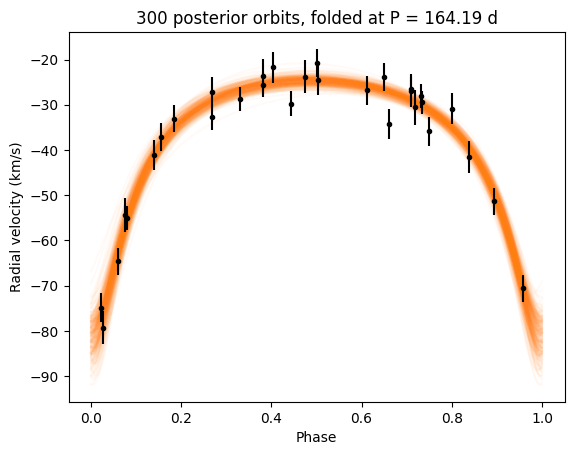

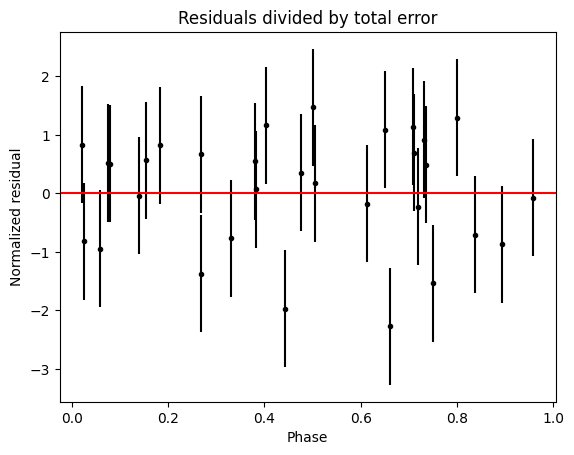

mean = 0.05, std = 0.97


In [94]:
P_med, Tp_med = np.median(P), np.median(Tp)
phase_data = ((t - Tp_med) / P_med) % 1
phase_grid = np.linspace(0, 1, 500)
tt = Tp_med + phase_grid * P_med

for j in np.random.choice(len(samples), 300, replace=False):
    plt.plot(phase_grid, kepler_rv(tt, P[j], K[j], e[j], omega[j], Tp[j], gamma[j]),
             color='C1', alpha=0.03)
plt.errorbar(phase_data, rv, np.sqrt(sig**2 + np.median(s)**2), fmt='.', color='k')
plt.xlabel('Phase')
plt.ylabel('Radial velocity (km/s)')
plt.title(f'300 posterior orbits, folded at P = {P_med:.2f} d')
plt.show()

log_prob = sampler.get_log_prob(discard=burn, thin=thin, flat=True)
j_best = np.argmax(log_prob)
model = kepler_rv(t, P[j_best], K[j_best], e[j_best], omega[j_best], Tp[j_best], gamma[j_best])
z = (rv - model) / np.sqrt(sig**2 + s[j_best]**2)

plt.errorbar(phase_data, z, 1, fmt='.', color='k')
plt.axhline(0, color='r')
plt.xlabel('Phase')
plt.ylabel('Normalized residual')
plt.title('Residuals divided by total error')
plt.show()
print(f"mean = {np.mean(z):.2f}, std = {np.std(z):.2f}")

The residuals are randomly scattered around 0 which is ideal as there is no systemic error across the entire phase.

**FINAL ANSWER:** P = 164.19 ± 0.42 d, K = 28.2 ± 1.8 km/s, e = 0.53 ± 0.03, gamma = -38.09 ± 0.68 km/s, s = 2.49 ± 0.54 km/s, f(M) = 0.235 ± 0.039 Mdot.


**Black-hole candidate?** No, f(M) was constrained to 0.235 and even the upper bound estimate of f(M) is also below the three solar masses that would signal a black hole candidate.

## Part 3: The referee report (35%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident MCMC analysis of this exact
problem, produced by an AI assistant. It runs top to bottom without errors, the corner plot is handsome, and
the prose is fluent. It is also wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks and
style don't count; "it used 24 walkers and I used 32" is not a finding).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset: show, with a number or a plot, what the error
   does to the inference. For a sampler, "demonstrate" usually means running it the wrong way and the right
   way and comparing. A demonstration can come out negative: if an error turns out not to move *your*
   numbers, showing that, and saying what it would take for it to bite, is a valid finding.
3. **State** the correct treatment (you built it in Part 2).

Third time you have done this. You should be finding these in minutes now.


1) The Likelihood estimator does not use an s term for jitter measuring the uncertainty and attributes all the error to randomness in their estimation pipeline. As seen many times, Copilot responses often provide overconfident error bars while ignoring a source of error (like the intrinsic scatter).

2) f(M) is calculated through medians of P K and e (unlike calculating it once per every posteirior sample). This uses correlated quantities towards the estimate which affects uncertainty estimate.

3) nsteps = 1500, their tau max is around 58, and therefore only around 26 tau would fit in the chain so the auto correlation time function stopped too early before any real convergence because the data range is too small

In [ ]:
#1
dof = t.size - 7
chi2_pipe = np.sum(((rv - model) / sig)**2) / dof # pipeline errors included
chi2_total = np.sum((rv - model)**2 / (sig**2 + s[j_best]**2)) / dof #total errors
print(f'chi2_pipe: {chi2_pipe:.2f}, chi2_total: {chi2_total:.2f}')

chi2_pipe: 3.75, chi2_total: 1.22


In [101]:
#2
Pm, Km, em = np.median(P), np.median(K), np.median(e)
fM_ai = mass_function(Pm, Km, em)
err_ai = fM_ai * np.sqrt((np.std(P)/Pm)**2 + (3*np.std(K)/Km)**2
                         + (3*em*np.std(e)/(1 - em**2))**2)
print(f'fM_ai: {fM_ai:.2f} +- err_ai: {err_ai:.2f}')
print(f'Percentiles: {np.percentile(fM, [16, 50, 84])}')

fM_ai: 0.23 +- err_ai: 0.05
Percentiles: [0.20066686 0.23549741 0.27756327]


In [ ]:
#3
print(1500 / tau.max(), 100 / tau.max())

short = emcee.EnsembleSampler(24, 7, log_posterior)
short.run_mcmc(best + 1e-4 * np.random.randn(24, 7), 1500)
try:
    short.get_autocorr_time()
except Exception as err:
    print(err)

17.73331463757189 1.1822209758381261
The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 30;
tau: [57.54255694 52.39196333 49.76170244 61.19465948 56.12415116 53.34122545
 62.85008405]


**REFEREE REPORT:**

The chi squared using the AI solution is over three times larger than the correct implementation which uses a jitter term in the log likelyhood function. The mass function error is greater than the one reported in my solution above which can be attributed to the fact that they calculate f(M) using the median parameters which may add future complications for analysis. For their tau, the number of samples (1500) was far too small for the most accurate results.



## Part 4: AI-use appendix and verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did you catch it? Honesty
   is graded; "I didn't use any" is fine if true.
2. **Reflection (new from this lab on, two or three sentences)**: what did you use AI for in this lab, and
   what would have gone wrong in your answer if you had not checked its output? Name the specific thing, not
   "it could have made a mistake".
3. **Verification plan**: the checks you ran before trusting your Part 2 numbers, and what failure would have
   looked like for each. One you should seriously consider: generate a synthetic RV curve with parameters
   you choose, at *your* epochs, run your whole Part 2 pipeline on it, and see whether the 68% intervals
   contain what you put in. With seven parameters and one realisation, expect about five of seven inside
   their 68% intervals; one pull of 2.5σ is not a failure by itself. Failure looks systematic: the same
   parameter off in the same direction every time, or an interval that never contains the truth.


**AI-USE APPENDIX:**
I used Claude chats starting with Part 2 to implement the more complex MCMC and corner plotting as those are completely new libraries to learn the syntax for, in creating the log prior and posterior functions, and in some of the less common plots and subplots for quick implementation and for standards across visualizations. I also asked for a physical background explanation of single-lined spectroscopic binaries including explanations of the keplerian model, the mass function, and the need for a periodogram. In VSCode, I also enabled to code in-line finisher which mostly is tedious (and should be better optimized), but rarely helps me reformat format srings or moving a plot into a loop makes the changes instantaneous (when truly recognizes them).

**REFLECTION:**
From the AI output in part two, it was necessary to go over each cell block (and also having Claude report justifications both statistically and given the physical context) while analyzing each plot or cell output/reported metric in order to write a short finding that the cell produced. To check, asking it to go back to plots or metrics may have prevented mistakes if the original output was incorrect.
**VERIFICATION PLAN:**
   - First compare the best log-likelihood across the 3 candidate periods. 
   - Make sure the chain got enough autocorrelation time before declaring convergance. Failure would be a warning or walkers stuck apart.
   - Residuals should be distributed equally across the phase. Failure would be structure in phase or a std far from 1. 
   - Simulating a fake star with known parameters and noise. 4/6 contained the truth, with no parameter off significantly from the one sigma interval. Failure would be the same parameter consistently biased or an interval that never contains the truth.



In [102]:
rv_real = rv.copy()
truth = best.copy()
P_t, K_t, e_t, om_t, Tp_t, g_t, s_t = unpack(truth)

np.random.seed(1)
rv = kepler_rv(t, P_t, K_t, e_t, om_t, Tp_t, g_t) + np.random.randn(t.size) * np.sqrt(sig**2 + s_t**2)

fake = emcee.EnsembleSampler(64, 7, log_posterior)
fake.run_mcmc(truth + 1e-4 * np.random.randn(64, 7), 10000)
fs = fake.get_chain(discard=420, thin=42, flat=True)

rv = rv_real

In [103]:
P_s, K_s, h_s, k_s, Tp_s, g_s, lns_s = fs.T
e_s = h_s**2 + k_s**2
fM_s = mass_function(P_s, K_s, e_s)

names = ['P', 'K', 'e', 'gamma', 's', 'f(M)']
true_vals = [P_t, K_t, e_t, g_t, s_t, mass_function(P_t, K_t, e_t)]
post = [P_s, K_s, e_s, g_s, np.exp(lns_s), fM_s]

for name, tv, x in zip(names, true_vals, post):
    lo, med, hi = np.percentile(x, [16, 50, 84])
    print(f"{name:6s} truth {tv:8.3f}  68% [{lo:8.3f}, {hi:8.3f}]  inside: {lo <= tv <= hi}  pull: {(tv - med) / np.std(x):.1f}")

P      truth  164.180  68% [ 163.550,  164.232]  inside: True  pull: 0.8
K      truth   28.512  68% [  25.264,   28.136]  inside: False  pull: 1.2
e      truth    0.531  68% [   0.456,    0.518]  inside: False  pull: 1.4
gamma  truth  -38.156  68% [ -39.037,  -37.971]  inside: True  pull: 0.6
s      truth    2.075  68% [   1.310,    2.534]  inside: True  pull: 0.2
f(M)   truth    0.240  68% [   0.188,    0.244]  inside: True  pull: 0.9
